# Projet Méthodes Stochastiques — notebook

Code et simulations du projet proie-prédateur avec virus. Le contexte, la démarche
et la discussion des résultats sont dans le rapport ; ce notebook se concentre sur
le code qui charge les données, estime les paramètres et régénère les figures.

## Question 1 — modèle du virus (`virus4.csv`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs

# Le fichier n'a pas d'en-tete : on nomme les colonnes a la main.
data = pd.read_csv("virus4.csv", header=None, names=["V", "P"])
V = data["V"].values
P = data["P"].values
N = len(data)
N

2000

### Estimation du pas de temps `dt`

In [2]:
# L'equation des predateurs est deterministe (dP = P(-1+V)dt) : on inverse le
# schema d'Euler pour estimer dt point par point, puis on moyenne. On ecarte les
# points ou V est proche de 1, qui annulent le denominateur.
dP = np.diff(P)
denom = P[:-1] * (-1 + V[:-1])
masque = np.abs(V[:-1] - 1) > 0.05

dt = np.mean(dP[masque] / denom[masque])
tau = N * dt
print(f"dt ~ {dt:.4f}, tau ~ {tau:.1f}")

dt ~ 0.0150, tau ~ 30.0


### Populations observées

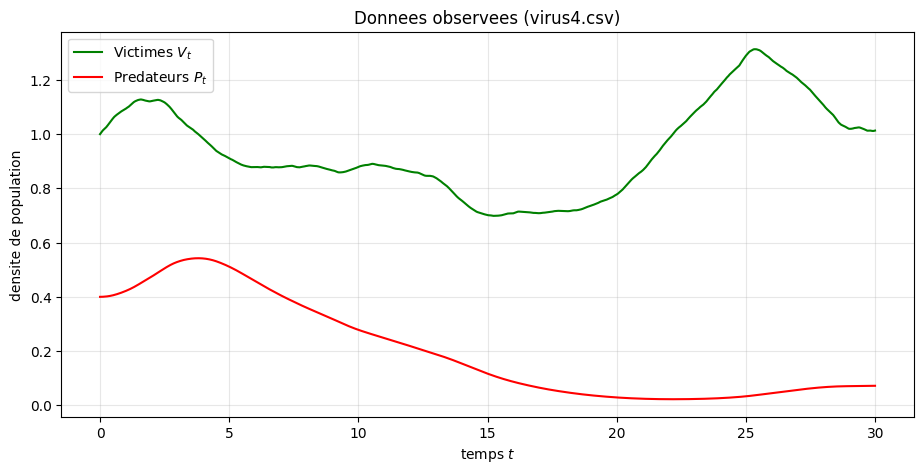

In [3]:
t = np.arange(N) * dt

plt.figure(figsize=(11, 5))
plt.plot(t, V, color="green", label="Victimes $V_t$")
plt.plot(t, P, color="red", label="Predateurs $P_t$")
plt.xlabel("temps $t$")
plt.ylabel("densite de population")
plt.title("Donnees observees (virus4.csv)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparaison avec le modèle de Lotka-Volterra classique (sans $X_t$)

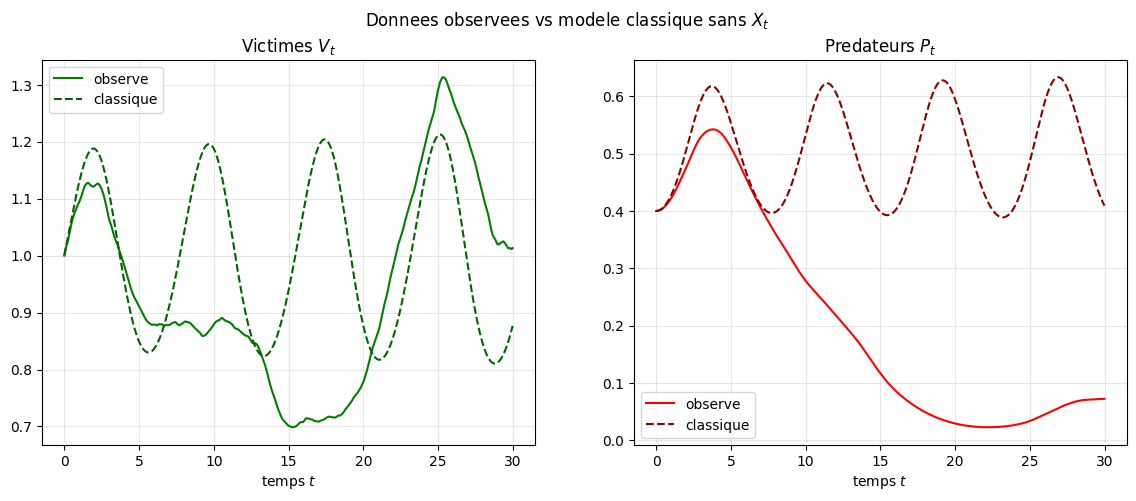

In [4]:
a, b, c, d = 2/3, 4/3, 1, 1

Vc = np.zeros(N)
Pc = np.zeros(N)
Vc[0], Pc[0] = V[0], P[0]   # memes conditions initiales que les donnees

# Euler explicite sur la meme grille de temps que les observations.
for i in range(N - 1):
    Vc[i+1] = Vc[i] + Vc[i] * (a - b * Pc[i]) * dt
    Pc[i+1] = Pc[i] + Pc[i] * (-c + d * Vc[i]) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Donnees observees vs modele classique sans $X_t$")

axes[0].plot(t, V, color="green", label="observe")
axes[0].plot(t, Vc, color="darkgreen", linestyle="--", label="classique")
axes[0].set_title("Victimes $V_t$")
axes[0].set_xlabel("temps $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, P, color="red", label="observe")
axes[1].plot(t, Pc, color="darkred", linestyle="--", label="classique")
axes[1].set_title("Predateurs $P_t$")
axes[1].set_xlabel("temps $t$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

### Reconstruction du virus $X_t$

In [5]:
# Discretisation directe de l'equation des proies :
#   V[i] - V[i-1] = V[i-1] (2/3 - 4/3 P[i-1] + X[i-1]) dt
# d'ou X[i-1] = (V[i]-V[i-1]) / (V[i-1] dt) - 2/3 + 4/3 P[i-1].
dV = np.diff(V)
X = dV / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]
tX = t[:-1]   # X[k] est attache au temps t[k]

# Artefact deterministe, sauvegarde pour que tout le monde reparte de la meme serie.
pd.DataFrame({"t": tX, "X": X}).to_csv("virus4_Xt.csv", index=False)
print(f"X reconstruit : {len(X)} points")

X reconstruit : 1999 points


### $X_t$ et ses incréments $\Delta X_t$

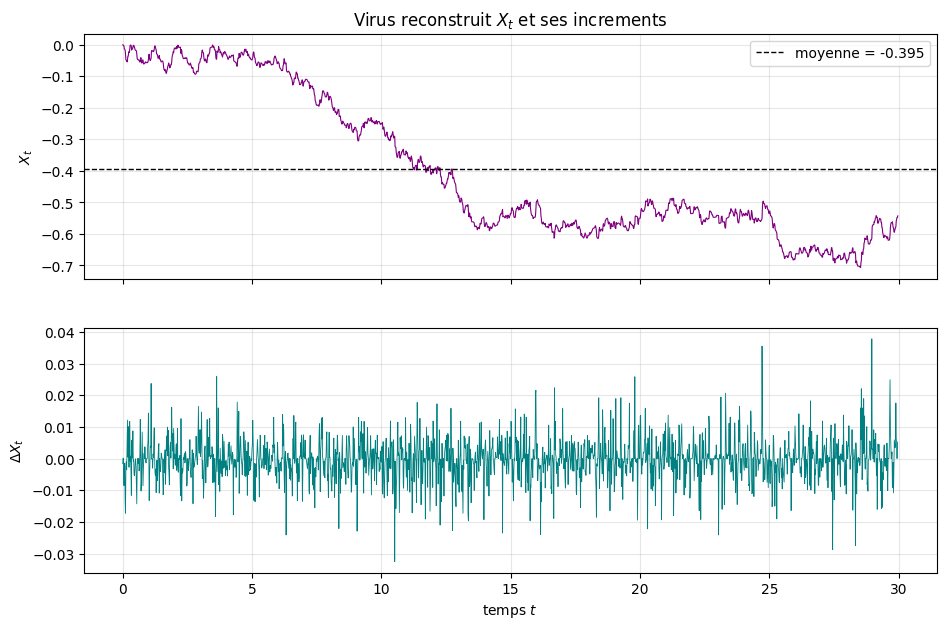

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(tX, X, color="purple", lw=0.8)
axes[0].axhline(X.mean(), color="black", ls="--", lw=1, label=f"moyenne = {X.mean():.3f}")
axes[0].set_ylabel("$X_t$")
axes[0].set_title("Virus reconstruit $X_t$ et ses increments")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(tX[:-1], np.diff(X), color="teal", lw=0.6)
axes[1].set_xlabel("temps $t$")
axes[1].set_ylabel(r"$\Delta X_t$")
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_Xt.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistiques de $X_t$ et $\Delta X_t$

Pour les incréments, l'écart-type brut dépend du pas `dt` ; l'échelle qui a un sens est le
coefficient de diffusion $\sigma = \text{std}(\Delta X)/\sqrt{dt}$. On regarde aussi
l'asymétrie et la kurtosis pour juger de la normalité des incréments.

In [7]:
dX = np.diff(X)
sigma = dX.std() / np.sqrt(dt)   # coefficient de diffusion, independant de dt

stats = pd.DataFrame(
    {"moyenne": [X.mean(), dX.mean()], "ecart-type": [X.std(), dX.std()]},
    index=["X_t", "dX_t"],
)
print(stats)
print(f"\nsigma = std(dX)/sqrt(dt) = {sigma:.4f}")
print(f"increments dX : asymetrie = {scs.skew(dX):.2f}, kurtosis exces = {scs.kurtosis(dX):.2f}")

       moyenne  ecart-type
X_t  -0.395169    0.227932
dX_t -0.000272    0.006381

sigma = std(dX)/sqrt(dt) = 0.0521
increments dX : asymetrie = 0.03, kurtosis exces = 3.33


### Gaussianité des incréments $\Delta X_t$

On compare l'histogramme des incréments à une loi normale de mêmes moyenne et écart-type.

test KS (normalite des increments) : D = 0.0881, p-value = 6.12e-14


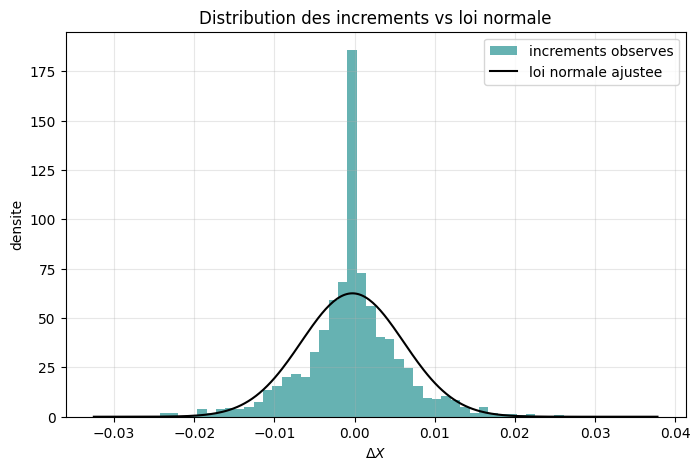

In [8]:
loi = scs.norm(dX.mean(), dX.std())   # normale calee sur moyenne et ecart-type des increments
ks = scs.kstest(dX, loi.cdf)
print(f"test KS (normalite des increments) : D = {ks.statistic:.4f}, p-value = {ks.pvalue:.2e}")
xx = np.linspace(dX.min(), dX.max(), 300)

plt.figure(figsize=(8, 5))
plt.hist(dX, bins=60, density=True, color="teal", alpha=0.6, label="increments observes")
plt.plot(xx, loi.pdf(xx), color="black", lw=1.5, label="loi normale ajustee")
plt.xlabel(r"$\Delta X$")
plt.ylabel("densite")
plt.title("Distribution des increments vs loi normale")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_dXt_hist.png", dpi=150, bbox_inches="tight")
plt.show()